In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

In [2]:
def get_dataset(db, data_dir=None):
    task_items = []
    servers_hist_all = []
    nodes = []
    net_measures = []
    if data_dir is not None:
        task_items = pd.read_csv('{}/tasks.gz'.format(data_dir)).to_dict('records')
        servers_hist_all = pd.read_csv('{}/servers.gz'.format(data_dir)).to_dict('records')
        nodes = pd.read_csv('{}/nodes.gz'.format(data_dir)).to_dict('records')
        net_measures = pd.read_csv('{}/net_measures.gz'.format(data_dir)).to_dict('records')
    else:
        task_items = db.get_items_in_collection(collection='tasks')
        servers_hist_all = db.get_items_in_collection(collection='servers_hist', sort=('time', 1))
        nodes  = db.get_items_in_collection(collection='nodes')
        net_measures = db.get_items_in_collection(collection='net_measures')

    # servers_hist_mec_on = db.get_items_in_collection(collection='servers_hist', query={'mec': True}, sort=('time', 1))
    servers_hist_mec_on = [t for t in servers_hist_all if t['mec']]
    # servers_hist_control = db.get_items_in_collection(collection='servers_hist', query={'control_loop': True}, sort=('time', 1))
    servers_hist_control = [t for t in servers_hist_all if t['control_loop']]
    nodes_map = {n['ip']: n['name'] for n in nodes}
    reference_time = task_items[0]['send_time']

    return [task_items, servers_hist_all, nodes, servers_hist_mec_on, servers_hist_control, nodes_map, reference_time, net_measures]

In [3]:
def calculate_geo_distance(lat_lon1, lat_lon2):
    R = 6373.0
    lat1 = math.radians(lat_lon1[0])
    lon1 = math.radians(lat_lon1[1])
    lat2 = math.radians(lat_lon2[0])
    lon2 = math.radians(lat_lon2[1])


    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    distance = R * c
    return distance

In [4]:
def process_data(gnd_dir, ground_cloud=True, dis_map={}):
       # Process ground data
    gnd_datasets = os.listdir(gnd_dir)
    distances = []
    names = []
    net_delays_mean = []
    net_delays_std = []
    net_delays_max = []
    net_delays_min = []
    net_mess = []
    ret_map = {} if ground_cloud else dis_map

    for dataset in gnd_datasets:
        gnd_data = get_dataset(None, gnd_dir + dataset)
        print('dataset', dataset)

        tasks = [t for t in gnd_data[0] if t['status']== 'Done']
        nodes = gnd_data[2]
        net_measures = gnd_data[7]
        # servers_hist = gnd_data[3]

        get_index = lambda n, l: l[[i for i, v  in enumerate(l) if  n in v['name'] ][0]]

        gnd_node = get_index('gn', nodes)

        if ground_cloud:
            gnd_gateway = get_index('gg101', nodes)
            geo_distance = calculate_geo_distance((gnd_node['latitude'], gnd_node['longitude']),
                                                (gnd_gateway['latitude'], gnd_gateway['longitude']) )
            print('geo distance',geo_distance, gnd_node['latitude'], gnd_node['longitude'])
            ret_map.update({str(gnd_node['latitude'])+str(gnd_node['longitude']) : geo_distance})
        else:
            geo_distance = dis_map[str(gnd_node['latitude'])+str(gnd_node['longitude'])]
            print('geo distance',geo_distance, gnd_node['latitude'], gnd_node['longitude'])

        # if gnd_node['latitude'] == -33.92:
        #     print('remove: ', dataset)

        
        distances.append(geo_distance)
        names.append(gnd_node['name'])

        
        # task_items, servers_hist_all, nodes, servers_hist_mec_on
        network_times = [t['computation_time'] for t in tasks]
        network_times = (np.array(network_times) - 0.25)*1000/5
        # print('mean network time', mean_time)
        net_delays_mean.append(np.mean(network_times))
        net_delays_std.append(np.std(network_times))
        net_delays_max.append(np.max(network_times))
        net_delays_min.append(np.min(network_times))
        net_mess.append(net_measures)

    i_s = np.argsort(distances)
    distances = np.array(distances)[i_s]
    net_delays_mean = np.array(net_delays_mean)[i_s]
    net_delays_max = np.array(net_delays_max)[i_s]
    net_delays_min = np.array(net_delays_min)[i_s]
    net_delays_std = np.array(net_delays_std)[i_s]
    names = np.array(names)[i_s]
    net_mess = [net_mess[i] for i in i_s]

    return distances, net_delays_mean, ret_map, (net_delays_max, net_delays_min, net_delays_std), net_mess

In [5]:
dataset_name = '100sats_1gnd_100dev_1200seconds_2orch_08-10-24_13-47-16'
# space_dir = 'data/sims/space_vs_ground/space/'


gnd_dir  = 'data/sims/space_vs_ground/ground/5ms/'
gnd_distances, gnd_net, dis_map, gnd_stats, n_mess_g = process_data(gnd_dir)


# Process space 1 server
space_dir_1 = 'data/sims/space_vs_ground/sats/1s/'
print(space_dir_1)
space_distances_1, space_net_1, _, space_1_stats, n_mess_1 = process_data(space_dir_1, False, dis_map)

# Process space 10 server inplane
space_dir_10 = 'data/sims/space_vs_ground/sats/10s_inplane/'
print(space_dir_10)
space_distances_10, space_net_10, _, space_10_stats, n_mess_10_in = process_data(space_dir_10, False, dis_map)

# Process space 10 server ecuatorial
space_dir_10_ec = 'data/sims/space_vs_ground/sats/10s_ecuatorial/'
print(space_dir_10_ec)
space_distances_10_ec, space_net_10_ec, _, space_10_ec_stats, n_mess_10_ec = process_data(space_dir_10_ec, False, dis_map)



dataset 100sats_2gnd_20dev_2700seconds_2orch_17-11-24_03-44-44
geo distance 2027.173579988717 39.9272 32.8644
dataset 100sats_2gnd_20dev_2700seconds_2orch_17-11-24_01-43-25
geo distance 11117.963881066102 -6.1744 106.8294
dataset 100sats_2gnd_20dev_2700seconds_2orch_16-11-24_21-14-30
geo distance 9069.688229461246 13.75 100.5166
dataset 100sats_2gnd_20dev_2700seconds_2orch_16-11-24_23-31-31
geo distance 9826.392284691497 35.685 139.7514
dataset 100sats_2gnd_20dev_2700seconds_2orch_17-11-24_02-44-07
geo distance 6489.297291478371 19.017 72.857
dataset 100sats_2gnd_20dev_2700seconds_2orch_16-11-24_20-13-44
geo distance 4660.352868765684 25.23 55.28
dataset 100sats_2gnd_20dev_2700seconds_2orch_16-11-24_22-30-51
geo distance 8770.881748987933 30.58 114.27
dataset 100sats_2gnd_20dev_2700seconds_2orch_17-11-24_00-42-41
geo distance 16321.435408787023 -27.455 153.0351
dataset 100sats_2gnd_20dev_2700seconds_2orch_17-11-24_05-45-49
geo distance 1543.0098837618682 55.9483 -3.2191
dataset 100sats

In [20]:
 matplotlib.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

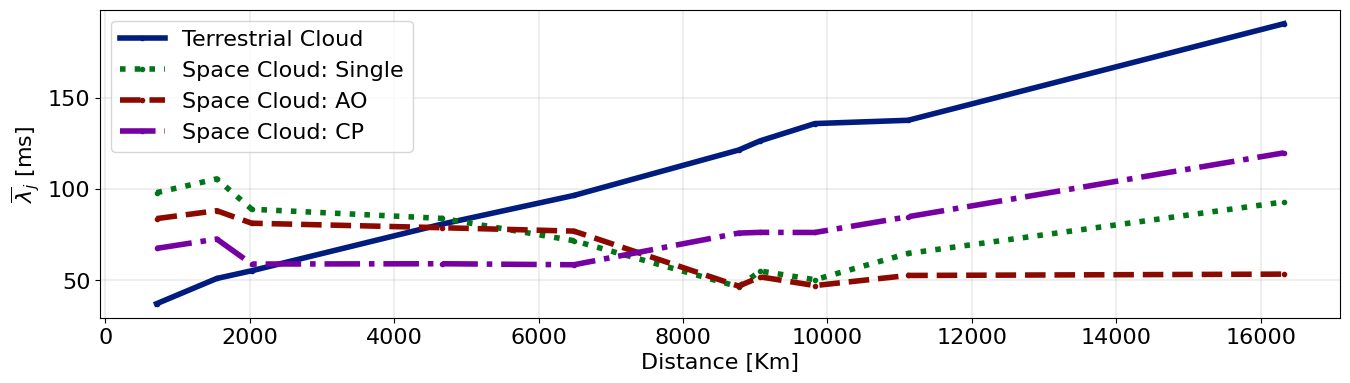

In [7]:
plt.style.use('seaborn-v0_8-dark-palette')
plt.rcParams['font.size'] = 16
lwidth= 4
fig, ax = plt.subplots(figsize=(16,4))
ax.plot(gnd_distances, gnd_net, label='Terrestrial Cloud', marker='.', linestyle='solid', linewidth=lwidth)
ax.plot(space_distances_1, space_net_1, label='Space Cloud: Single', marker='.', linestyle='dotted',linewidth=lwidth)
ax.plot(space_distances_10, space_net_10, label='Space Cloud: AO', marker='.',linestyle='dashed', linewidth=lwidth)
ax.plot(space_distances_10_ec, space_net_10_ec, label='Space Cloud: CP', marker='.', linestyle='dashdot', linewidth=lwidth)
ax.set_ylabel("$\overline{\lambda}_j$ [ms]")
ax.set_xlabel('Distance [Km]')


plt.legend()

plt.grid(linewidth=0.3)
plt.savefig('mean_latency.pdf', bbox_inches="tight", format='pdf')
# plt.show()

In [10]:
import pandas as pd



# gnd_distances, gnd_net, dis_map, gnd_stats, gnd_names = process_data(gnd_dir)
# space_distances_1, space_net_1, _, space_1_stats, _ = process_data(space_dir_1, False, dis_map)
# space_distances_10, space_net_10, _, space_10_stats, _ = process_data(space_dir_10, False, dis_map)
# space_distances_10_ec, space_net_10_ec, _, space_10_ec_stats, _ = process_data(space_dir_10_ec, False, dis_map)


# dis_map

coords_list = dis_map.keys()

coords_names = ['gn6', 'gn3', 'gn5', 'gn9', 'gn10','gn1','gn7', 'gn8', 'gn2', 'gn4']

names_dict = {}

n_dict={}

for i, coord in enumerate(coords_list):
    names_dict.update({coords_names[i]: int(dis_map[coord])})
    n_dict.update({coord:coords_names[i]})

data = np.array([np.array([int(k[2:]), k, names_dict[k]]) for k in names_dict.keys()])

data = data.T

# data
# print(data)

data_dict = {'id': data[0].astype(int), 'name': data[1], 'distances': data[2].astype(int)}
df = pd.DataFrame(data_dict)
df = df.sort_values('distances')
df['gnd_avg'] = gnd_net
df['gnd_std'] = gnd_stats[2]
# df['gnd_max'] = gnd_stats[0]
# df['gnd_min'] = gnd_stats[1]

df['sin_avg'] = space_net_1
df['sin_std'] = space_1_stats[2]
# df['sin_max'] = space_1_stats[0]
# df['sin_min'] = space_1_stats[1]

df['pl_avg'] = space_net_10
df['pl_std'] = space_10_stats[2]
# df['pl_max'] = space_10_stats[0]
# df['pl_min'] = space_10_stats[1]

df['eq_avg'] = space_net_10_ec
df['eq_std'] = space_10_ec_stats[2]
# df['eq_max'] = space_10_ec_stats[0]
# df['eq_min'] = space_10_ec_stats[1]


df.to_csv('result.csv')

# df.dtypes

# gnd_names


In [20]:
# print(names_dict)
# print(coords_list)

def hops_in_mess(mess):
    minutes = []
    hops = []
    i = 0
    sub_hops = []
    for mi in range(35):
        i += 1
        sub_mess = [m for m in mess if m['sim_time'] >= mi*60 and m['sim_time'] < (mi+1)*60]
        if len(sub_mess) > 0:
            # minutes.append((mi+1) * 5)
            # print(np.unique([m['switch'] for m in sub_mess]))
            sub_hops.append(len(np.unique([m['switch'] for m in sub_mess])))
        if i % 5 == 0:
            if len(sub_hops) > 0:
                minutes.append(i)
                hops.append(np.mean(sub_hops)) 
                sub_hops = []
    # print(minutes)
    return minutes, hops
    


# print(gn4_net_g)






print(gnd_distances)
# n_mess_g[0]

[  709.57137988  1543.00988376  2027.17357999  4660.35286877
  6489.29729148  8770.88174899  9069.68822946  9826.39228469
 11117.96388107 16321.43540879]


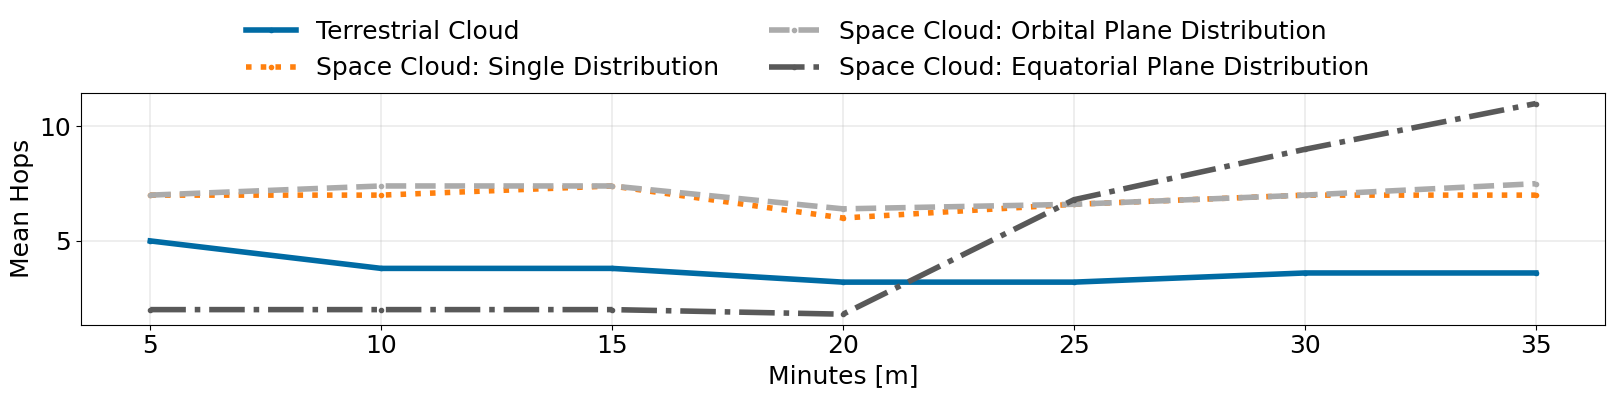

In [22]:
#net data gn4 (index 2)

fsize = 18
lwidth= 4
# matplotlib.rcParams.update({'font.size': fsize})
gn4_net_g = n_mess_g[2]
gn4_net_1 = n_mess_1[2]
gn4_net_10_in = n_mess_10_in[2]
gn4_net_10_ec = n_mess_10_ec[2]

gn4_g_t, gn4_g_h = hops_in_mess(gn4_net_g)
gn4_1_t, gn4_1_h = hops_in_mess(gn4_net_1)
gn4_10in_t, gn4_10in_h = hops_in_mess(gn4_net_10_in)
gn4_10ec_t, gn4_10ec_h = hops_in_mess(gn4_net_10_ec)


plt.style.use('tableau-colorblind10')
plt.rcParams['font.size'] = fsize
fig, ax = plt.subplots(figsize=(16,3))
# ax.plot(gnd_distances, gnd_net, label='Ground Cloud', marker='.', linestyle='solid')
# ax.plot(space_distances_1, space_net_1, label='Space Cloud: Single Distribution', marker='.', linestyle='dotted')
# ax.plot(space_distances_10, space_net_10, label='Space Cloud: Orbital Plane Distribution', marker='.',linestyle='dashed')
# ax.plot(space_distances_10_ec, space_net_10_ec, label='Space Cloud: Equatorial Plane Distribution', marker='.', linestyle='dashdot')

# print(gn4_1_t, )

plt.plot(gn4_g_t, gn4_g_h, label='Terrestrial Cloud', marker='.', linestyle='solid', linewidth=lwidth)
plt.plot(gn4_1_t, gn4_1_h, label='Space Cloud: Single Distribution', marker='.', linestyle='dotted', linewidth=lwidth)
plt.plot(gn4_10in_t, gn4_10in_h, label='Space Cloud: Orbital Plane Distribution', marker='.',linestyle='dashed', linewidth=lwidth)
plt.plot(gn4_10ec_t, gn4_10ec_h, label='Space Cloud: Equatorial Plane Distribution', marker='.', linestyle='dashdot', linewidth=lwidth)

# print(gn4_g_t)
# print(gn4_1_t)
# print(gn4_10in_t)
# print(gn4_10ec_t)

ax.set_ylabel("Mean Hops")
ax.set_xlabel('Minutes [m]')
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.31), frameon=False)
fig.tight_layout(pad=0.1, rect= (0.0, 0.0, 1, 1))
plt.grid(linewidth=0.3)
plt.savefig('mean_hops_gn4.pdf', bbox_inches="tight", format='pdf')

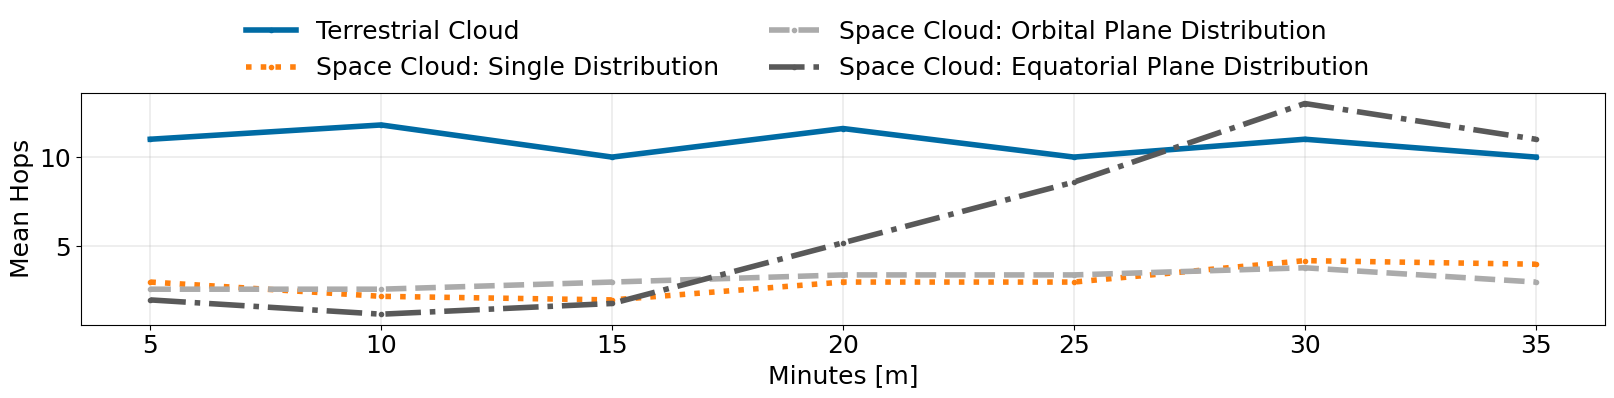

In [24]:
#net data gn10 (index 7)

fsize = 18
lwidth= 4
gn4_net_g = n_mess_g[7]
gn4_net_1 = n_mess_1[7]
gn4_net_10_in = n_mess_10_in[7]
gn4_net_10_ec = n_mess_10_ec[7]

gn4_g_t, gn4_g_h = hops_in_mess(gn4_net_g)
gn4_1_t, gn4_1_h = hops_in_mess(gn4_net_1)
gn4_10in_t, gn4_10in_h = hops_in_mess(gn4_net_10_in)
gn4_10ec_t, gn4_10ec_h = hops_in_mess(gn4_net_10_ec)


plt.style.use('tableau-colorblind10')
plt.rcParams['font.size'] = fsize
fig, ax = plt.subplots(figsize=(16,3))
# ax.plot(gnd_distances, gnd_net, label='Ground Cloud', marker='.', linestyle='solid')
# ax.plot(space_distances_1, space_net_1, label='Space Cloud: Single Distribution', marker='.', linestyle='dotted')
# ax.plot(space_distances_10, space_net_10, label='Space Cloud: Orbital Plane Distribution', marker='.',linestyle='dashed')
# ax.plot(space_distances_10_ec, space_net_10_ec, label='Space Cloud: Equatorial Plane Distribution', marker='.', linestyle='dashdot')

# print(gn4_1_t, )

plt.plot(gn4_g_t, gn4_g_h, label='Terrestrial Cloud', marker='.', linestyle='solid', linewidth=lwidth)
plt.plot(gn4_1_t, gn4_1_h, label='Space Cloud: Single Distribution', marker='.', linestyle='dotted', linewidth=lwidth)
plt.plot(gn4_10in_t, gn4_10in_h, label='Space Cloud: Orbital Plane Distribution', marker='.',linestyle='dashed', linewidth=lwidth)
plt.plot(gn4_10ec_t, gn4_10ec_h, label='Space Cloud: Equatorial Plane Distribution', marker='.', linestyle='dashdot', linewidth=lwidth)

# print(gn4_g_t)
# print(gn4_1_t)
# print(gn4_10in_t)
# print(gn4_10ec_t)

ax.set_ylabel("Mean Hops")
ax.set_xlabel('Minutes [m]')
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.31), frameon=False)
fig.tight_layout(pad=0.1, rect= (0.0, 0.0, 1, 1))
plt.grid(linewidth=0.3)
plt.savefig('mean_hops_gn10.pdf', bbox_inches="tight", format='pdf')


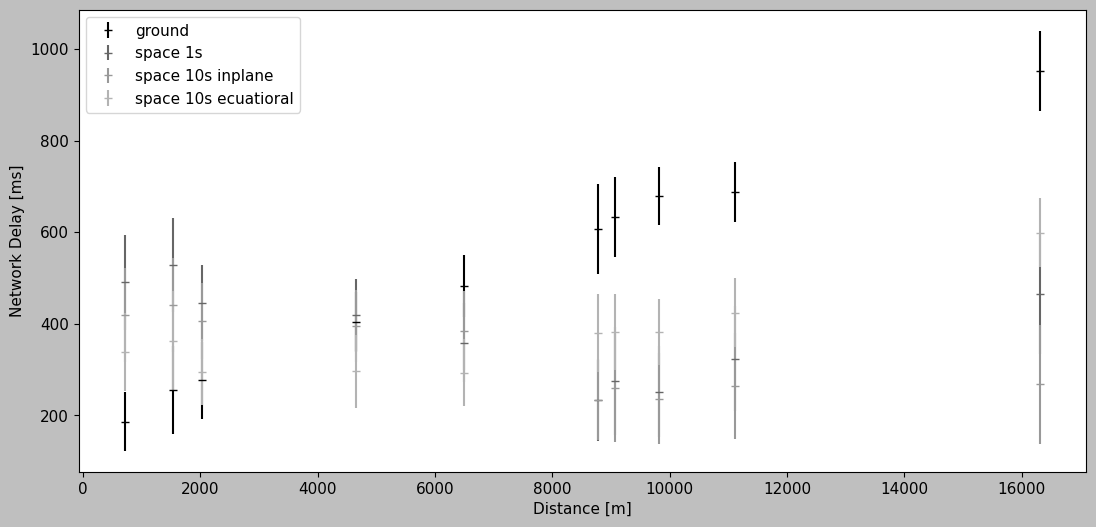

In [18]:
fig, ax = plt.subplots(figsize=(13,6))

ax.errorbar(gnd_distances, gnd_net, yerr=gnd_stats[2], label='ground', marker='_', linestyle='')
ax.errorbar(space_distances_1, space_net_1, label='space 1s', marker='_', yerr=space_1_stats[2], linestyle='')
ax.errorbar(space_distances_10, space_net_10, label='space 10s inplane', marker='_', yerr=space_1_stats[2], linestyle='')
ax.errorbar(space_distances_10_ec, space_net_10_ec, label='space 10s ecuatioral', marker='_', yerr=space_10_stats[2], linestyle='')
ax.set_ylabel('Network Delay [ms]')
ax.set_xlabel('Distance [m]')
ax.legend()
plt.show()


[[-30.29854708 -21.58695358  -3.67033726  21.66710352  37.95536191
   45.463353    50.12565064  59.62851644  52.80252384  70.70080061]
 [-46.6040867  -37.11383911 -26.0248706    1.93638883  19.53708204
   74.51514598  74.4952692   88.69792969  84.96405558 137.10557496]
 [-60.82300361 -54.52470966 -33.68118069  -3.18143078  24.78164328
   74.86956005  71.29780604  85.50195936  72.89327186  97.58145476]]
[[-30.29854708 -21.58695358  -3.67033726  21.66710352  37.95536191
   45.463353    50.12565064  59.62851644  52.80252384  70.70080061]
 [-46.6040867  -37.11383911 -26.0248706    1.93638883  19.53708204
   74.51514598  74.4952692   88.69792969  84.96405558 137.10557496]
 [-60.82300361 -54.52470966 -33.68118069  -3.18143078  24.78164328
   74.86956005  71.29780604  85.50195936  72.89327186  97.58145476]]


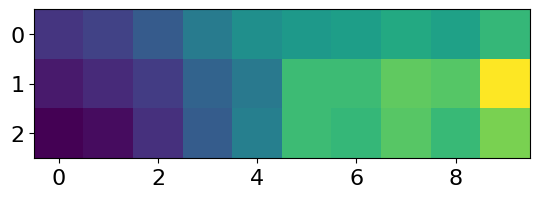

In [12]:


# fig, ax = plt.subplots()
# print(X)
# ax.imshow(X)

# plt.show()

[[-30.29854708 -21.58695358  -3.67033726  21.66710352  37.95536191
   45.463353    50.12565064  59.62851644  52.80252384  70.70080061]
 [-46.6040867  -37.11383911 -26.0248706    1.93638883  19.53708204
   74.51514598  74.4952692   88.69792969  84.96405558 137.10557496]
 [-60.82300361 -54.52470966 -33.68118069  -3.18143078  24.78164328
   74.86956005  71.29780604  85.50195936  72.89327186  97.58145476]]


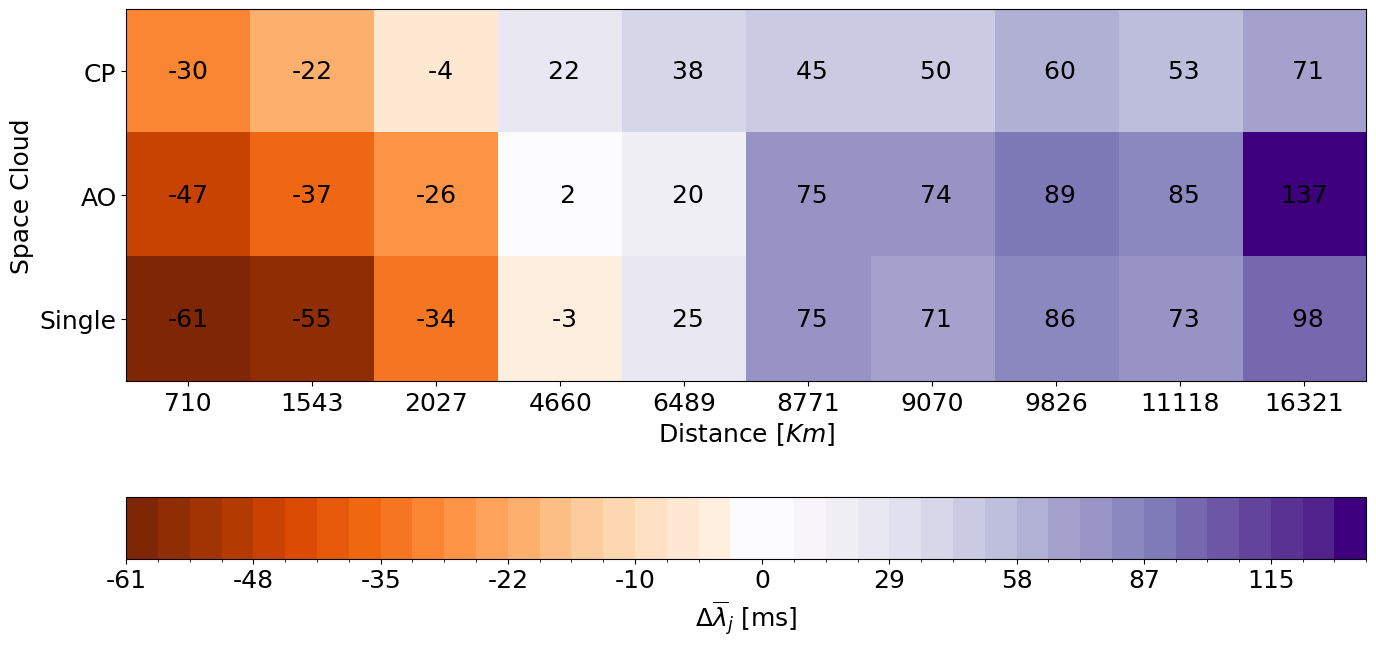

In [13]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib as mlp


# gnd_distances, gnd_net
# space_distances_1, space_net_1
# space_distances_10, space_net_10
# space_distances_10_ec, space_net_10_ec

x1 =  gnd_net - space_net_1
x2 =  gnd_net - space_net_10
x3 = gnd_net - space_net_10_ec

# cmaplist =['red', 'green']






X = np.array([x3, x2, x1])
# X = 1000*X
bounds = np.linspace(np.min(X),np.max(X),5)
print(X)



n_colors= 20

cmapg = mlp.colormaps['Purples'].resampled(n_colors)
cmapr = mlp.colormaps['Oranges'].resampled(n_colors)

# define the colormap
cmap = plt.cm.jet
cmaplist = [cmapr(i) for i in range(cmapr.N)][::-1] + [cmapg(i) for i in range(cmapg.N)]
cmap = cmap.from_list('Custom cmap', cmaplist, cmapg.N + cmapr.N)

bounds = np.array([np.linspace(np.min(X), 0.0, n_colors), np.linspace(0.0, np.max(X), n_colors)]).flatten()
norm = BoundaryNorm(bounds, cmap.N)
plt.rcParams['font.size'] = 18

# ax.plot(space_distances_1, space_net_1, label='Space Cloud: Single Distribution', marker='.', linestyle='dotted')
# ax.plot(space_distances_10, space_net_10, label='Space Cloud: Orbital Plane Distribution', marker='.',linestyle='dashed')
# ax.plot(space_distances_10_ec, space_net_10_ec, label='Space Cloud: Equatorial Plane Distribution', marker='.', linestyle='dashdot')
fig, ax = plt.subplots(figsize=(16,10))

im = ax.imshow(X,interpolation='none',norm=norm, cmap=cmap)
ax.set_xticks(np.arange(X.shape[1]), labels=['{:3.0f}'.format(d) for d in gnd_distances])
ax.set_yticks(np.arange(X.shape[0]), labels=['CP', 'AO', 'Single' ])
ax.set_ylabel('Space Cloud')
ax.set_xlabel('Distance [$Km$]')


for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        text = ax.text(j, i, '{:3.0f}'.format(X[i, j]),
                       ha="center", va="center", color="black")
plt.colorbar(im,location="bottom", format='%.0f', label="$\Delta \overline{\\lambda}_j$ [ms]")
plt.savefig('mean_latency_comparison.pdf', bbox_inches="tight", format='pdf')
plt.show()


In [10]:
dis_1 = np.sort(gnd_distances)
dis_2 = np.sort(space_distances_10)
dis_3 = np.sort(space_distances_10_ec)
dis_4 = np.sort(space_distances_1)

print(dis_map)


# print(dis_1 - dis_2, dis_1 -dis_3, dis_1 - dis_4)
print(dis_2)

print(space_distances_10, space_net_10)
# ax.scatter(space_distances_1, space_net_1, label='space 1s')
# ax.scatter(space_distances_10, space_net_10, label='space 10s inplane')
# ax.scatter(space_distances_10_ec, space_net_10_ec, label='space 10s ecuatioral')

{'13.75100.5166': 9069.688229461246, '-27.455153.0351': 16321.435408787023, '25.2355.28': 4660.352868765684, '39.927232.8644': 2027.173579988717, '-6.1744106.8294': 11117.963881066102, '48.216.3666': 709.5713798776893, '30.58114.27': 8770.881748987933, '19.01772.857': 6489.297291478371, '55.9483-3.2191': 1543.0098837618682, '35.685139.7514': 9826.392284691497}
[  709.57137988  1543.00988376  2027.17357999  4660.35286877
  6489.29729148  8770.88174899  9069.68822946  9826.39228469
 11117.96388107 16321.43540879]
[  709.57137988  1543.00988376  2027.17357999  4660.35286877
  6489.29729148  8770.88174899  9069.68822946  9826.39228469
 11117.96388107 16321.43540879] [0.41924623 0.44093063 0.40664613 0.39432529 0.38500586 0.2343677
 0.25972274 0.23592825 0.26363534 0.26727317]
